# Setup

In [ ]:
import sys
from pathlib import Path

sys.path.append(Path.cwd().parent.parent.joinpath("src").as_posix())

print(sys.path[-1])
# for p in sys.path:
#   print(p)

DATA_PATH = Path.cwd().parent.parent.joinpath("data/keras")
print(f"DATA_PATH={DATA_PATH}")

import keras
import numpy as np
import matplotlib.pyplot as plt

print('keras', keras.__version__)
print('NumPy', np.__version__)
import matplotlib
print('matplotlib', matplotlib.__version__)

d:/workspace/github/hack-modeling/ml/codes/hands-on-ml/src
DATA_PATH=d:\workspace\github\hack-modeling\ml\codes\hands-on-ml\data\keras
keras 3.11.3
NumPy 2.3.2
matplotlib 3.10.6


In [28]:
from keras import layers, optimizers, losses, metrics, activations, regularizers

# Generalization

In [2]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

train_images

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)

In [4]:
train_images_with_noise_channels = np.concatenate(
  [train_images, np.random.random((len(train_images), 784))],
  axis=1)
train_images_with_zeros_channels = np.concatenate(
  [train_images, np.zeros((len(train_images), 784))],
  axis=1)
train_images_with_noise_channels, train_images_with_zeros_channels

(array([[0.        , 0.        , 0.        , ..., 0.67937045, 0.87509716,
         0.01093055],
        [0.        , 0.        , 0.        , ..., 0.09935927, 0.71582615,
         0.19141953],
        [0.        , 0.        , 0.        , ..., 0.22844434, 0.15188458,
         0.31669362],
        ...,
        [0.        , 0.        , 0.        , ..., 0.10455534, 0.34980502,
         0.84772531],
        [0.        , 0.        , 0.        , ..., 0.6862121 , 0.64465124,
         0.59322198],
        [0.        , 0.        , 0.        , ..., 0.79203152, 0.55311377,
         0.30709235]], shape=(60000, 1568)),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 1568)))

In [7]:
def get_model():
  model = keras.Sequential([
    layers.Dense(512, activation=activations.relu),
    layers.Dense(10, activation=activations.softmax)
  ])
  model.compile(optimizer=optimizers.RMSprop(),
                loss=losses.sparse_categorical_crossentropy,
                metrics=[metrics.sparse_categorical_accuracy])
  return model

In [8]:
model = get_model()
history_noise = model.fit(train_images_with_noise_channels, train_labels,
                          epochs=10, batch_size=128, validation_split=0.2)
history_zeros = model.fit(train_images_with_zeros_channels, train_labels,
                          epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6179 - sparse_categorical_accuracy: 0.8103 - val_loss: 0.4015 - val_sparse_categorical_accuracy: 0.8794
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2568 - sparse_categorical_accuracy: 0.9209 - val_loss: 0.2214 - val_sparse_categorical_accuracy: 0.9323
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1676 - sparse_categorical_accuracy: 0.9488 - val_loss: 0.1555 - val_sparse_categorical_accuracy: 0.9549
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1198 - sparse_categorical_accuracy: 0.9631 - val_loss: 0.1399 - val_sparse_categorical_accuracy: 0.9580
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0887 - sparse_categorical_accuracy: 0.9720 - val_loss: 0.1217 - val_sparse_categorical_accuracy: 0.9643
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0639 - sparse_categorical_accuracy: 0.9793 - val_loss: 0.1260 - val_sparse_categorical_accuracy: 0.9609
Epo

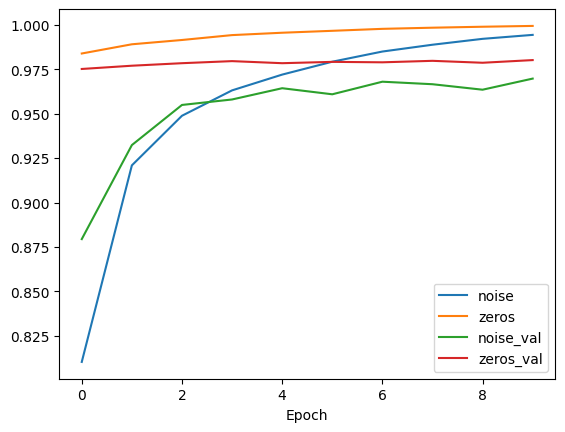

In [ ]:
# from util.tf import plot_history
# plot_history(history_noise)
# plot_history(history_zeros)

# noise features lead to overfitting
plt.plot(history_noise.epoch, history_noise.history['sparse_categorical_accuracy'], label='noise')
plt.plot(history_noise.epoch, history_zeros.history['sparse_categorical_accuracy'], label='zeros')
plt.plot(history_noise.epoch, history_noise.history['val_sparse_categorical_accuracy'], label='noise_val')
plt.plot(history_noise.epoch, history_zeros.history['val_sparse_categorical_accuracy'], label='zeros_val')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Regularization

In [14]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000) # keep top most frequently words

# prepare data: multi-hot encoding
def vectorize_sequences(sequences, dimension=10000):
  result = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
      result[i,j] = 1.
  return result

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype(np.float32)
y_test = np.asarray(test_labels).astype(np.float32)
x_train, y_train

(array([[0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        ...,
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.],
        [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000)),
 array([1., 0., 0., ..., 0., 1., 0.], shape=(25000,), dtype=float32))

In [15]:
model = keras.Sequential([
  layers.Dense(16, activation=activations.relu),
  layers.Dense(16, activation=activations.relu),
  layers.Dense(1, activation=activations.sigmoid)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history = model.fit(x_train, y_train,                     
                    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - binary_accuracy: 0.7506 - loss: 0.5910 - val_binary_accuracy: 0.8346 - val_loss: 0.4761
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8768 - loss: 0.3937 - val_binary_accuracy: 0.8787 - val_loss: 0.3493
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9069 - loss: 0.2868 - val_binary_accuracy: 0.8855 - val_loss: 0.2987
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9237 - loss: 0.2272 - val_binary_accuracy: 0.8906 - val_loss: 0.2784
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9359 - loss: 0.1894 - val_binary_accuracy: 0.8842 - val_loss: 0.2802
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.9469 - loss: 0.1599 - val_binary_accuracy: 0.8844 - val_loss: 0.2857
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9545 - loss: 0.1378 - val_binary_accuracy: 0.8869 - val_loss: 0.2899
Epoch 8/20
30

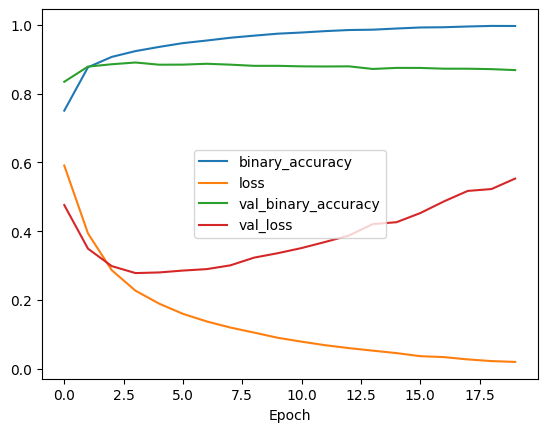

In [16]:
from util.tf import plot_history
plot_history(history)

In [17]:
# smaller model
model = keras.Sequential([
  layers.Dense(4, activation=activations.relu),
  layers.Dense(4, activation=activations.relu),
  layers.Dense(1, activation=activations.sigmoid)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history_smaller = model.fit(x_train, y_train,                     
                    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - binary_accuracy: 0.7309 - loss: 0.6432 - val_binary_accuracy: 0.8153 - val_loss: 0.5873
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8587 - loss: 0.5416 - val_binary_accuracy: 0.8392 - val_loss: 0.5087
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8923 - loss: 0.4557 - val_binary_accuracy: 0.8710 - val_loss: 0.4366
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.9060 - loss: 0.3828 - val_binary_accuracy: 0.8817 - val_loss: 0.3827
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.9140 - loss: 0.3260 - val_binary_accuracy: 0.8854 - val_loss: 0.3439
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.9219 - loss: 0.2821 - val_binary_accuracy: 0.8891 - val_loss: 0.3163
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.9284 - loss: 0.2482 - val_binary_accuracy: 0.8884 - val_loss: 0.3025
Epoch 8/20
30/3

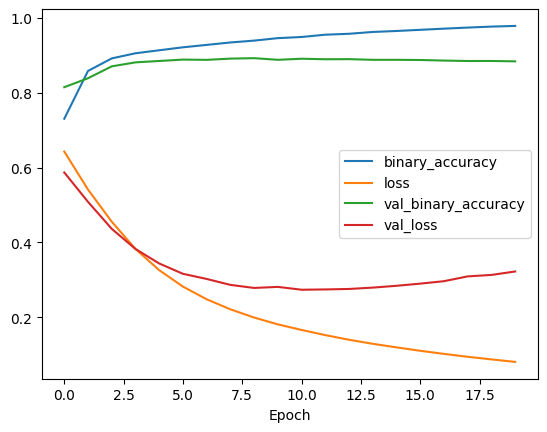

In [18]:
from util.tf import plot_history
plot_history(history_smaller)

In [19]:
# larger model
model = keras.Sequential([
  layers.Dense(512, activation=activations.relu),
  layers.Dense(512, activation=activations.relu),
  layers.Dense(1, activation=activations.sigmoid)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history_larger = model.fit(x_train, y_train,                     
                    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - binary_accuracy: 0.7164 - loss: 0.5719 - val_binary_accuracy: 0.8364 - val_loss: 0.3863
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - binary_accuracy: 0.8568 - loss: 0.3381 - val_binary_accuracy: 0.8782 - val_loss: 0.3022
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - binary_accuracy: 0.9070 - loss: 0.2375 - val_binary_accuracy: 0.8582 - val_loss: 0.3345
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - binary_accuracy: 0.9315 - loss: 0.1786 - val_binary_accuracy: 0.8887 - val_loss: 0.2790
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - binary_accuracy: 0.9413 - loss: 0.1584 - val_binary_accuracy: 0.8747 - val_loss: 0.2920
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - binary_accuracy: 0.9632 - loss: 0.1117 - val_binary_accuracy: 0.8854 - val_loss: 0.3121
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - binary_accuracy: 0.9757 - loss: 0.0709 - val_binary_accuracy: 0.8841 - val_loss: 0.3648
Epoch 8/20
30

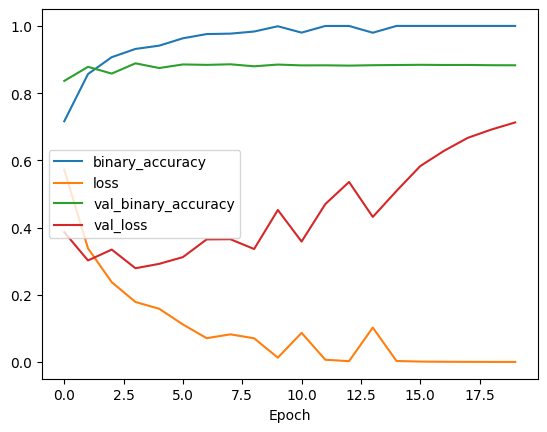

In [20]:
from util.tf import plot_history
plot_history(history_larger)

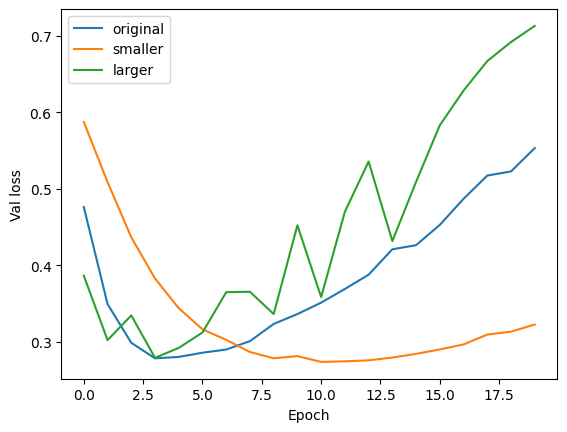

In [25]:
# comparison
plt.plot(history.epoch, history.history['val_loss'], label='original')
plt.plot(history_smaller.epoch, history_smaller.history['val_loss'], label='smaller')
plt.plot(history_larger.epoch, history_larger.history['val_loss'], label='larger')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.legend()
plt.show()

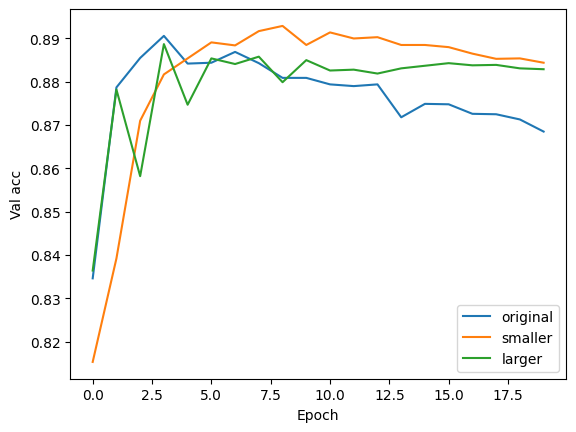

In [27]:
plt.plot(history.epoch, history.history['val_binary_accuracy'], label='original')
plt.plot(history_smaller.epoch, history_smaller.history['val_binary_accuracy'], label='smaller')
plt.plot(history_larger.epoch, history_larger.history['val_binary_accuracy'], label='larger')
plt.xlabel('Epoch')
plt.ylabel('Val acc')
plt.legend()
plt.show()

## Weight Regularization

In [29]:
model = keras.Sequential([
  layers.Dense(16, 
               kernel_regularizer=regularizers.l2(0.002),
               activation=activations.relu),
  layers.Dense(16, 
               kernel_regularizer=regularizers.l2(0.002),
               activation=activations.relu),
  layers.Dense(1, activation=activations.sigmoid)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history_l2_reg = model.fit(x_train, y_train,                     
                    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - binary_accuracy: 0.7887 - loss: 0.6113 - val_binary_accuracy: 0.8586 - val_loss: 0.4908
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.8855 - loss: 0.4173 - val_binary_accuracy: 0.8817 - val_loss: 0.3981
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.9097 - loss: 0.3429 - val_binary_accuracy: 0.8647 - val_loss: 0.4026
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.9203 - loss: 0.3091 - val_binary_accuracy: 0.8873 - val_loss: 0.3619
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.9271 - loss: 0.2880 - val_binary_accuracy: 0.8866 - val_loss: 0.3585
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.9363 - loss: 0.2704 - val_binary_accuracy: 0.8839 - val_loss: 0.3649
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.9378 - loss: 0.2581 - val_binary_accuracy: 0.8832 - val_loss: 0.3639
Epoch 8/20
30

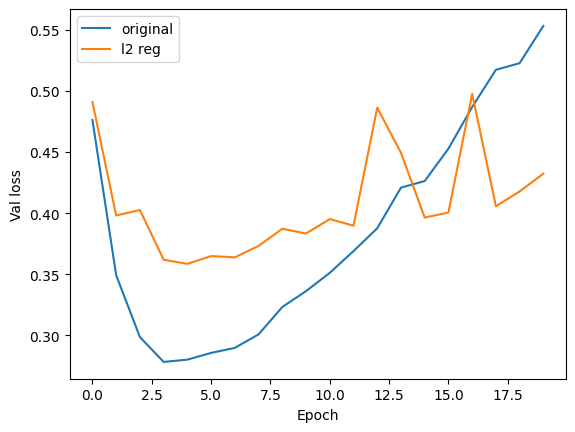

In [30]:
# comparison
plt.plot(history.epoch, history.history['val_loss'], label='original')
plt.plot(history_l2_reg.epoch, history_l2_reg.history['val_loss'], label='l2 reg')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.legend()
plt.show()

## Dropout

In [31]:
model = keras.Sequential([
  layers.Dense(16, activation=activations.relu),
  layers.Dropout(0.5),
  layers.Dense(16, activation=activations.relu),
  layers.Dropout(0.5),
  layers.Dense(1, activation=activations.sigmoid)
])

model.compile(optimizer=optimizers.RMSprop(),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
history_dropout = model.fit(x_train, y_train,                     
                    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.6295 - loss: 0.6412 - val_binary_accuracy: 0.8329 - val_loss: 0.5451
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.7491 - loss: 0.5419 - val_binary_accuracy: 0.8663 - val_loss: 0.4437
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8061 - loss: 0.4667 - val_binary_accuracy: 0.8802 - val_loss: 0.3847
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.8412 - loss: 0.4086 - val_binary_accuracy: 0.8827 - val_loss: 0.3347
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8656 - loss: 0.3623 - val_binary_accuracy: 0.8798 - val_loss: 0.3118
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.8853 - loss: 0.3234 - val_binary_accuracy: 0.8801 - val_loss: 0.2995
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.8985 - loss: 0.2919 - val_binary_accuracy: 0.8881 - val_loss: 0.2908
Epoch 8/20
30

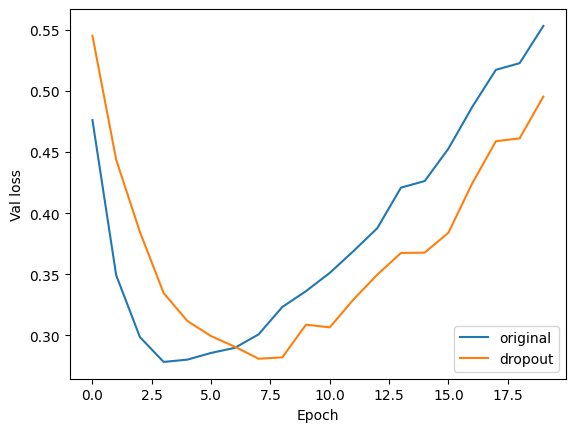

In [33]:
# comparison
plt.plot(history.epoch, history.history['val_loss'], label='original')
plt.plot(history_dropout.epoch, history_dropout.history['val_loss'], label='dropout')
plt.xlabel('Epoch')
plt.ylabel('Val loss')
plt.legend()
plt.show()